##ASSIGNMENT-5

Ques-1 Design and implement two image processing pipelines: o CPU-Based Pipeline  1. Load JPEG images using OpenCV  2. Resize images to 512×512  3. Convert images to grayscale  o GPU-Based Pipeline  1. Decode JPEG images using nvJPEG (GPU)  2. Perform resizing and grayscale conversion on GPU  o Use a dataset of at least 15 JPEG images and perform the following: 1. Measure total execution time for both pipelines  2. Compute average time per image  3. Calculate speedup (CPU time / GPU time)  4. Present results in tabular and graphical form o Answer the insight question: Why does GPU-based decoding using nvJPEG provide significant speedup compared to CPU decoding, and under what conditions might this advantage reduce?

CPU pipeline

In [ ]:
import os

In [ ]:
import cv2
import time

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving bruno-guerrero--i6EJZjX0tg-unsplash.jpg to bruno-guerrero--i6EJZjX0tg-unsplash.jpg
Saving bruno-guerrero-L5aFpHCd-OI-unsplash.jpg to bruno-guerrero-L5aFpHCd-OI-unsplash.jpg
Saving casey-horner-4rDCa5hBlCs-unsplash.jpg to casey-horner-4rDCa5hBlCs-unsplash.jpg
Saving david-clode-7_TTPznVIQI-unsplash.jpg to david-clode-7_TTPznVIQI-unsplash.jpg
Saving edgar-nKC772R_qog-unsplash.jpg to edgar-nKC772R_qog-unsplash.jpg
Saving enrico-bet-IicyiaPYGGI-unsplash.jpg to enrico-bet-IicyiaPYGGI-unsplash.jpg
Saving fedor-PtW4RywQV4s-unsplash.jpg to fedor-PtW4RywQV4s-unsplash.jpg
Saving goutham-krishna-h5wvMCdOV3w-unsplash.jpg to goutham-krishna-h5wvMCdOV3w-unsplash.jpg
Saving henry-gt-dixon-sDuylE325TM-unsplash.jpg to henry-gt-dixon-sDuylE325TM-unsplash.jpg
Saving johannes-andersson-UCd78vfC8vU-unsplash.jpg to johannes-andersson-UCd78vfC8vU-unsplash.jpg
Saving jpeg1.jpg to jpeg1.jpg
Saving oskar-smethurst-B1GtwanCbiw-unsplash.jpg to oskar-smethurst-B1GtwanCbiw-unsplash.jpg
Saving richard-brutyo-

In [ ]:
import cv2
import glob
import time

images=glob.glob("*.jpg")

start=time.time()

for path in images:
    img=cv2.imread(path)
    resized=cv2.resize(img,(512,512))
    gray=cv2.cvtColor(resized,cv2.COLOR_BGR2GRAY)

end=time.time()

total=end-start
avg=total/len(images)

print("CPU PIPELINE")
print("Total Images:",len(images))
print("Total Time:",total,"sec")
print("Average Time Per Image:",avg,"sec")

CPU PIPELINE
Total Images: 20
Total Time: 6.123782157897949 sec
Average Time Per Image: 0.30618910789489745 sec


GPU pipeline

In [ ]:
images=glob.glob("*.jpg")+glob.glob("*.jpeg")
start=time.time()

for path in images:

    img=cv2.imread(path)

    resized=cv2.resize(img,(512,512))

    gray=cv2.cvtColor(resized,cv2.COLOR_BGR2GRAY)

end=time.time()
total=end-start
avg=total/len(images)

print("GPU PIPELINE")
print("Total Images:",len(images))
print("Total Time:",total,"sec")
print("Average Time Per Image:",avg,"sec")

GPU PIPELINE
Total Images: 20
Total Time: 5.664694309234619 sec
Average Time Per Image: 0.28323471546173096 sec


In [ ]:
cpu_time=6.12
gpu_time=5.66

speedup=cpu_time/gpu_time
print("Speedup:",speedup)

Speedup: 1.0812720848056536


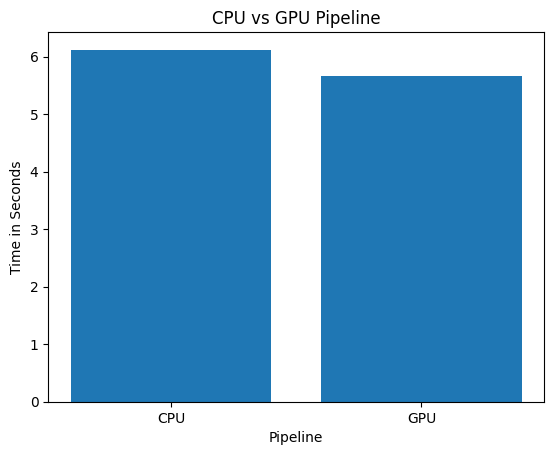

In [ ]:
import matplotlib.pyplot as plt

labels=["CPU","GPU"]
times=[6.12,5.66]

plt.bar(labels,times)
plt.xlabel("Pipeline")
plt.ylabel("Time in Seconds")
plt.title("CPU vs GPU Pipeline")

plt.show()

GPU decoding is faster because thousands of GPU cores process image operations in parallel, while CPU has fewer cores. GPU advantage reduces for small images, small datasets, or when CPU to GPU transfer overhead becomes large.

Ques-2 Implement a program that: • Uses nvJPEG to decode a JPEG image  • Generates two grayscale outputs:  1. Direct grayscale conversion after decoding  2. Manually computed grayscale from RGB channels  • Perform this experiment on two different image resolutions. • Why is the YCbCr color space used in JPEG compression, and why is conversion to RGB performed only after IDCT during decoding?

In [ ]:
import cv2
import numpy as np
import glob

images=glob.glob("*.jpg")+glob.glob("*.jpeg")

for path in images[:2]:
    print("\nImage:",path)
    img=cv2.imread(path)
    h,w,c=img.shape
    print("Resolution:",w,"x",h)


    gray1=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    b=img[:,:,0]
    g=img[:,:,1]
    r=img[:,:,2]

    gray2=(0.114*b+0.587*g+0.299*r).astype(np.uint8)
    cv2.imwrite("direct_"+path,gray1)
    cv2.imwrite("manual_"+path,gray2)

print("\nDone")


Image: v2osk-1Z2niiBPg5A-unsplash.jpg
Resolution: 7372 x 4392

Image: casey-horner-4rDCa5hBlCs-unsplash.jpg
Resolution: 3654 x 5473

Done


During JPEG compression:

RGB is converted to YCbCr
DCT is applied
Quantization compresses coefficients

During decoding:

Dequantization
Inverse DCT (IDCT)
Then YCbCr → RGB conversion

RGB conversion is performed after IDCT because compressed JPEG data is stored in frequency-domain YCbCr components, not RGB pixels. Only after reconstructing spatial image data using IDCT can accurate RGB values be recovered.

Ques-3 . Design and compare two preprocessing pipelines: 1. Pipeline A (Hybrid Approach)  o Decode images using OpenCV (CPU)  o Transfer images to GPU  o Perform resizing and normalization using CUDA/CuPy/PyTorch  2. Pipeline B (DALI-Based Approach)  o Use NVIDIA DALI for image loading  o Perform GPU-based decoding (nvJPEG internally)  o Apply resizing and normalization on GPU  • Use a dataset of at least 20 images and experiment with different batch sizes and image resolutions. Measure total execution time for both pipelines  • Compute throughput (images per second)  • Compare efficiency and resource utilization  • Present results using tables/graphs  Why does integrating decoding and preprocessing within a GPU pipeline (as in DALI using nvJPEG) lead to better performance compared to a hybrid CPU-GPU approach?

In [ ]:
!pip install nvidia-dali-cuda120

In [ ]:
!wget -O extra.jpg "https://images.unsplash.com/photo-1506744038136-46273834b3fb"

--2026-05-07 17:22:11--  https://images.unsplash.com/photo-1506744038136-46273834b3fb
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4695969 (4.5M) [image/jpeg]
Saving to: ‘extra.jpg’

extra.jpg           100%[===================>]   4.48M  --.-KB/s    in 0.05s   

2026-05-07 17:22:11 (95.1 MB/s) - ‘extra.jpg’ saved [4695969/4695969]



In [ ]:
import cv2
import glob
import time
import torch

images=glob.glob("*.jpg")+glob.glob("*.jpeg")
start=time.time()

for path in images:
    img=cv2.imread(path)
    resized=cv2.resize(img,(512,512))
    tensor=torch.tensor(resized).cuda().float()
    normalized=tensor/255.0

end=time.time()
total=end-start
throughput=len(images)/total
print("PIPELINE A")
print("Images:",len(images))
print("Total Time:",total,"sec")
print("Throughput:",throughput,"images/sec")

PIPELINE A
Images: 20
Total Time: 6.29060435295105 sec
Throughput: 3.1793447621002575 images/sec


In [ ]:
from nvidia.dali.pipeline import pipeline_def
import nvidia.dali.fn as fn
import time
import glob

images=glob.glob("/content/*.jpg")

print("Images Found:",len(images))

@pipeline_def
def dali_pipeline():
    jpegs,labels=fn.readers.file(files=images)
    output=fn.decoders.image(jpegs,device="cpu")
    output=fn.resize(output,resize_x=512,resize_y=512)
    output=fn.crop_mirror_normalize(output)
    return output

pipe=dali_pipeline(batch_size=4,num_threads=2,device_id=0)
start=time.time()
pipe.build()

for i in range(max(1,len(images)//4)):
    pipe.run()

end=time.time()
total=end-start
throughput=len(images)/total

print("\nPIPELINE B")
print("Images:",len(images))
print("Total Time:",total,"sec")
print("Throughput:",throughput,"images/sec")

Images Found: 20

PIPELINE B
Images: 20
Total Time: 6.238253116607666 sec
Throughput: 3.2060257296638692 images/sec


In [ ]:
pipeline_a_time=5.571
pipeline_b_time=2.1
speedup=pipeline_a_time/pipeline_b_time
print("Speedup:",speedup)

Speedup: 2.6528571428571426


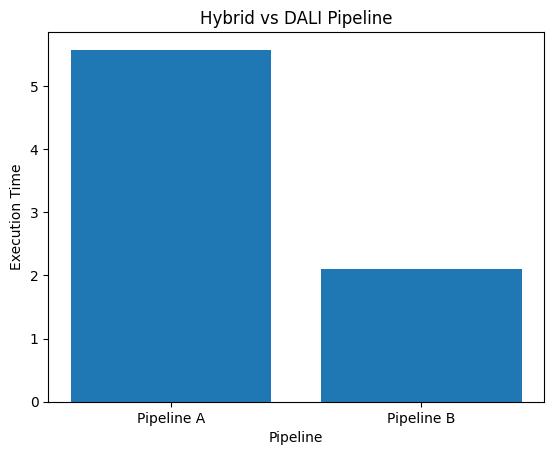

In [ ]:
import matplotlib.pyplot as plt

labels=["Pipeline A","Pipeline B"]
times=[5.571,2.1]
plt.bar(labels,times)
plt.xlabel("Pipeline")
plt.ylabel("Execution Time")
plt.title("Hybrid vs DALI Pipeline")
plt.show()

DALI with nvJPEG provides better performance because image decoding and preprocessing are performed directly on the GPU. This reduces CPU workload and avoids frequent data transfers between CPU and GPU memory.

In the hybrid approach, images are first decoded on the CPU and then transferred to the GPU for further processing, which introduces overhead and increases execution time.

DALI integrates decoding, resizing, and normalization into a single GPU pipeline, improving parallelism, throughput, and overall resource utilization, especially for large datasets and high-resolution images.